## Synapse summaries

### Goal: count how many synapses are between the cells in the OB network

Notes:
- All GCs are sources and all MCs and TCs are dest's
- The json defines all the connections so if "is_reciprocal": true, it means there is a recirocal connection
- Gap junctions are created in olfactorybulb > model.py but the .json synapses file only includes the MC/GC and TC/GC synapses

In [1]:
import json
import yaml
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d


In [2]:
import random
def find_apic_strings(json_data):
    apic_list = []

    def parse_dict(d):
        for key, value in d.items():
            if isinstance(value, dict):
                parse_dict(value)
            elif isinstance(value, list):
                parse_list(value)
            elif isinstance(value, str) and "apic" in value:
                apic_list.append(value)

    def parse_list(lst):
        for item in lst:
            if isinstance(item, dict):
                parse_dict(item)
            elif isinstance(item, list):
                parse_list(item)
            elif isinstance(item, str) and "apic" in item:
                apic_list.append(item)

    parse_dict(json_data)
    return apic_list

In [4]:
random.seed(42)
# define directory where slice .json files are located and slice name
slices_dir = os.path.join('/home/ellismith/OlfactoryBulb-1/olfactorybulb/slices_local')
slice_name = 'DorsalColumnSlice'

# import file into a dictionary
with open(f'{slices_dir}/{slice_name}/{"GCs"}.json','r') as f:
    data = json.load(f)
    apic_strings = find_apic_strings(data)

sampled_apics = random.sample(apic_strings, 100)
sampled_apics

['GC4[36].apic[5]',
 'GC3[54].apic[9]',
 'GC1[2].apic[8]',
 'GC1[94].apic[4]',
 'GC3[116].apic[1]',
 'GC3[104].apic[3]',
 'GC3[96].apic[7]',
 'GC3[64].apic[2]',
 'GC3[300].apic[3]',
 'GC3[50].apic[7]',
 'GC3[272].apic[8]',
 'GC1[94].apic[6]',
 'GC3[210].apic[1]',
 'GC4[4].apic[8]',
 'GC1[72].apic[6]',
 'GC4[28].apic[2]',
 'GC3[18].apic[4]',
 'GC3[18].apic[8]',
 'GC1[8].apic[6]',
 'GC5[26].apic[7]',
 'GC2[4].apic[8]',
 'GC3[196].apic[2]',
 'GC4[34].apic[2]',
 'GC1[2].apic[5]',
 'GC3[222].apic[6]',
 'GC3[86].apic[9]',
 'GC5[64].apic[4]',
 'GC3[262].apic[4]',
 'GC3[288].apic[6]',
 'GC4[28].apic[7]',
 'GC5[26].apic[3]',
 'GC3[178].apic[6]',
 'GC1[72].apic[9]',
 'GC5[28].apic[4]',
 'GC3[0].apic[6]',
 'GC3[306].apic[8]',
 'GC5[14].apic[1]',
 'GC4[40].apic[3]',
 'GC4[28].apic[1]',
 'GC3[136].apic[5]',
 'GC3[68].apic[0]',
 'GC5[24].apic[5]',
 'GC5[70].apic[8]',
 'GC5[34].apic[2]',
 'GC1[8].apic[8]',
 'GC5[42].apic[0]',
 'GC4[8].apic[8]',
 'GC3[142].apic[6]',
 'GC1[44].apic[8]',
 'GC3[238].apic

In [1]:
def get_synapses(file_name, slices_dir, slice_name):
    """
    args: 
    file_name: str (e.g. 'GCs__MCs')
    slices_dir: location of the synapses .json files
    slice_name: str (e.g. 'DorsalColumnSlice')
    """

    source_cells = []
    inh_cell_sections = []   
    source_cell_ids = []
    dest_cells = []    # i.e. TC4[2]
    exc_cell_sections = []     # i.e. "TC4[2].dend[7]"
    dest_cell_ids = []     # i.e. 2


    # import file into a dictionary
    with open(f'{slices_dir}/{slice_name}/{file_name}.json','r') as f:
        cells = json.load(f)

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        # get the source and destination cell types (first three characters, i.e. MC5, MC4, ...) 
        source_cell = entry['source_section'].split('.')[0]
        inh_cell_section = entry['source_section']
        source_cells.append(source_cell)
        inh_cell_sections.append(inh_cell_section)
        exc_cell_section = entry['dest_section']
        dest_cell = entry['dest_section'].split('.')[0]
        dest_cells.append(dest_cell)
        exc_cell_sections.append(exc_cell_section)

        # to get the cell number that's inside the brackets
        source_cell_id = int(source_cell[3:][1:-1])
        source_cell_ids.append(source_cell_id)
        dest_cell_id = int(dest_cell[3:][1:-1])
        dest_cell_ids.append(dest_cell_id)

        # check that all synapses are reciprocal
        assert entry['is_reciprocal'] == True 

        # check that all weights are 1
        assert entry['weight'] == 1.0
        
    # ordering the GCs and MC/TCs in order of cell type number using only unique cell id's
    inh_cells = sorted(set(source_cells))
    #print("inh cells:", inh_cells)
    print("inh cells:", inh_cells)
    exc_cells = sorted(set(dest_cells))
    print("exc cells:", exc_cells)

    # initialize DataFrame
    syn_df = pd.DataFrame(0, columns = inh_cells, index = exc_cells)

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        source_cell = entry['source_section'].split('.')[0]
        dest_cell = entry['dest_section'].split('.')[0]
        # increment synapse counts - all GCs are sources and all MCs and TCs are dest's
        syn_df.loc[dest_cell][source_cell] = syn_df.loc[dest_cell][source_cell] + 1

    syn_df.loc[:,'Row_Total'] = syn_df.sum(axis=1)
    syn_df.loc['Column_Total']= syn_df.sum(axis=0)

    # write DataFrame to pickle (for reimporting as a DataFrame) and yaml (for viewing) files
    #syn_df.to_pickle(f'{slices_dir}/{file_name}_synapse_counts.pkl', protocol=3)
    #with open(f'{slices_dir}/{file_name}_synapse_counts.yaml', 'w') as outfile:
    #    yaml.dump(syn_df.to_dict(),outfile)

    return syn_df, inh_cell_sections, exc_cell_sections, exc_cells, inh_cells


In [3]:
def get_cropped_df(df):
    # to get rid of the sum row and column 
    df.drop(df.tail(1).index,inplace=True)
    df.drop(columns=['Row_Total'], inplace=True)
    df = df
    return df

In [4]:
def get_syn_maxmin_df(df):
    
    df.loc[:, 'Row_Max'] = df.max(axis=1)

    maxValueIndex = df.idxmax(axis=1)     # find the column name of max values in every row
    df['Max_idx'] = np.array(maxValueIndex)
    df.loc['Column_Max'] = df.max(axis=0)

    df.loc[:, 'Row_Min'] = df.min(axis=1)
    df.loc['Column_Min'] = df.min(axis=0)
    return df

In [5]:
def plot_synapse_heatmap(df):
    ##syn_df.sort_index(level=0, ascending=True, inplace=True)
    get_cropped_df(df)
    fig, ax = plt.subplots(figsize=(15, 5))
    
    sns.heatmap(df, cmap="Blues")

In [6]:
def get_cell_info(file_name, slices_dir, slice_name):
    
    radii = []      # the (x,y,z) coordinates of each cell soma
    children = []   # 
    names = []

    # import file into a dictionary
    with open(f'{slices_dir}/{slice_name}/{file_name}.json','r') as f:
        cells = json.load(f)

    for root in cells['roots']:
        radii_cell = root['radii']
        radii.append(radii_cell)
        children_cell = root['children']
        children.append(children_cell)
        name = root['name'].split('.')[0]
        names.append(name)
    
    return radii, children, names

### Define location of slice files  

In [115]:
# define directory where slice .json files are located and slice name
slices_dir = os.path.join('/home/ellismith/OlfactoryBulb-1/olfactorybulb/slices_local')
slice_name = 'DorsalColumnSlice_20um'

### MC-GC synapses

In [116]:
# gc_sect_to_mc is a list of which GC sections form synapses with MCs
# gcs_conn_to_mcs is a list of which GCs form synapses with MCs
mc_syn_df, gc_sect_to_mc, mc_sect_to_gc, mcs_conn_to_gcs, gcs_conn_to_mcs = get_synapses('GCs__MCs', slices_dir, slice_name)
mc_syn_df1 =mc_syn_df.iloc[:,-11:]   # to show just a portion of the dataframe
mc_syn_df1

inh cells: ['GC1[0]', 'GC1[12]', 'GC1[16]', 'GC1[18]', 'GC1[22]', 'GC1[24]', 'GC1[28]', 'GC1[2]', 'GC1[30]', 'GC1[32]', 'GC1[36]', 'GC1[38]', 'GC1[42]', 'GC1[44]', 'GC1[46]', 'GC1[48]', 'GC1[52]', 'GC1[54]', 'GC1[8]', 'GC2[0]', 'GC2[2]', 'GC2[4]', 'GC3[0]', 'GC3[100]', 'GC3[102]', 'GC3[104]', 'GC3[106]', 'GC3[108]', 'GC3[110]', 'GC3[112]', 'GC3[114]', 'GC3[116]', 'GC3[118]', 'GC3[120]', 'GC3[122]', 'GC3[124]', 'GC3[136]', 'GC3[138]', 'GC3[140]', 'GC3[142]', 'GC3[144]', 'GC3[14]', 'GC3[150]', 'GC3[156]', 'GC3[160]', 'GC3[162]', 'GC3[166]', 'GC3[168]', 'GC3[170]', 'GC3[172]', 'GC3[18]', 'GC3[20]', 'GC3[22]', 'GC3[24]', 'GC3[26]', 'GC3[28]', 'GC3[30]', 'GC3[34]', 'GC3[36]', 'GC3[38]', 'GC3[40]', 'GC3[44]', 'GC3[4]', 'GC3[50]', 'GC3[54]', 'GC3[56]', 'GC3[58]', 'GC3[60]', 'GC3[62]', 'GC3[64]', 'GC3[66]', 'GC3[68]', 'GC3[6]', 'GC3[72]', 'GC3[74]', 'GC3[76]', 'GC3[80]', 'GC3[82]', 'GC3[84]', 'GC3[86]', 'GC3[88]', 'GC3[90]', 'GC3[92]', 'GC3[96]', 'GC3[98]', 'GC4[0]', 'GC4[10]', 'GC4[12]', 'GC4

,GC5[28],GC5[2],GC5[30],GC5[32],GC5[34],GC5[38],GC5[42],GC5[44],GC5[4],GC5[8],Row_Total
MC4[0],0,7,0,3,0,0,11,0,0,1,369
MC4[2],0,14,0,6,0,9,0,0,0,2,396
MC5[0],0,0,3,0,0,8,0,0,0,0,369
MC5[10],0,0,0,0,7,0,0,1,0,0,194
MC5[12],0,0,0,27,0,0,1,0,3,0,441
MC5[14],0,0,0,0,0,0,0,0,0,0,396
MC5[2],0,0,0,0,9,0,0,0,0,0,249
MC5[4],0,0,4,0,0,12,1,0,0,0,419
MC5[6],0,7,0,0,0,0,10,0,4,0,327
MC5[8],8,0,5,0,0,2,0,0,0,1,459


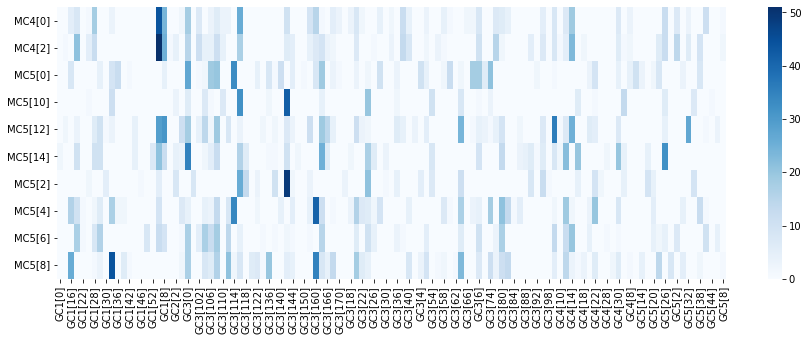

In [117]:
plot_synapse_heatmap(mc_syn_df)

In [118]:
mc_syn_df_ = get_syn_maxmin_df(mc_syn_df)
mc_syn_df_

,GC1[0],GC1[12],GC1[16],GC1[18],GC1[22],GC1[24],GC1[28],GC1[2],GC1[30],GC1[32],...,GC5[32],GC5[34],GC5[38],GC5[42],GC5[44],GC5[4],GC5[8],Row_Max,Max_idx,Row_Min
MC4[0],0,0,5,8,0,1,18,0,0,3,...,3,0,0,11,0,0,1,44,GC1[54],0
MC4[2],0,1,0,21,0,5,12,0,0,0,...,6,0,9,0,0,0,2,51,GC1[54],0
MC5[0],0,0,8,0,0,0,0,4,0,9,...,0,0,8,0,0,0,0,33,GC3[114],0
MC5[10],0,0,0,0,0,1,0,0,0,11,...,0,7,0,0,1,0,0,42,GC3[142],0
MC5[12],0,2,0,3,0,0,6,10,1,3,...,27,0,0,1,0,3,0,36,GC4[0],0
MC5[14],2,0,0,10,0,0,10,10,0,0,...,0,0,0,0,0,0,0,35,GC3[0],0
MC5[2],0,0,0,0,0,2,0,0,5,0,...,0,9,0,0,0,0,0,49,GC3[142],0
MC5[4],0,0,16,10,1,0,2,6,0,17,...,0,0,12,1,0,0,0,41,GC3[160],0
MC5[6],0,0,0,17,1,0,8,16,0,0,...,0,0,0,10,0,4,0,20,GC4[14],0
MC5[8],0,0,26,0,0,0,1,3,0,44,...,0,0,2,0,0,0,1,44,GC1[32],0


### TC-GC synapses

In [119]:
tc_syn_df, gc_sect_to_tc, tc_sect_to_gc, tcs_conn_to_gcs, gcs_conn_to_tcs = get_synapses('GCs__TCs', slices_dir, slice_name)
pd.set_option('display.max_rows', None)
tc_syn_df1 =tc_syn_df.iloc[:,-11:] # show subset of GCs
tc_syn_df1

inh cells: ['GC1[12]', 'GC1[16]', 'GC1[18]', 'GC1[28]', 'GC1[2]', 'GC1[30]', 'GC1[32]', 'GC1[54]', 'GC1[8]', 'GC3[0]', 'GC3[102]', 'GC3[104]', 'GC3[106]', 'GC3[108]', 'GC3[114]', 'GC3[116]', 'GC3[142]', 'GC3[156]', 'GC3[160]', 'GC3[162]', 'GC3[168]', 'GC3[20]', 'GC3[24]', 'GC3[36]', 'GC3[50]', 'GC3[54]', 'GC3[64]', 'GC3[72]', 'GC3[74]', 'GC3[80]', 'GC3[90]', 'GC4[0]', 'GC4[12]', 'GC4[14]', 'GC4[16]', 'GC4[20]', 'GC4[22]', 'GC4[30]', 'GC4[4]', 'GC4[8]', 'GC5[20]', 'GC5[24]', 'GC5[30]', 'GC5[32]', 'GC5[38]', 'GC5[42]']
exc cells: ['TC3[0]', 'TC3[2]', 'TC3[4]', 'TC3[6]', 'TC4[0]', 'TC4[10]', 'TC4[12]', 'TC4[14]', 'TC4[16]', 'TC4[2]', 'TC4[4]', 'TC4[6]', 'TC4[8]', 'TC5[0]', 'TC5[10]', 'TC5[12]', 'TC5[14]', 'TC5[16]', 'TC5[18]', 'TC5[20]', 'TC5[2]', 'TC5[4]', 'TC5[6]', 'TC5[8]']


,GC4[22],GC4[30],GC4[4],GC4[8],GC5[20],GC5[24],GC5[30],GC5[32],GC5[38],GC5[42],Row_Total
TC3[0],0,0,0,0,0,3,0,0,0,0,44
TC3[2],0,0,0,0,0,0,0,0,0,0,15
TC3[4],0,0,0,0,0,0,0,0,0,0,20
TC3[6],0,0,0,0,0,0,0,0,0,0,28
TC4[0],0,0,0,0,3,17,0,0,20,0,246
TC4[10],0,0,0,0,0,32,5,0,0,0,218
TC4[12],0,5,0,0,0,0,0,0,0,0,138
TC4[14],0,0,0,0,0,26,0,0,0,0,242
TC4[16],0,0,0,0,0,0,0,0,0,0,92
TC4[2],12,0,0,0,0,22,0,0,1,0,352


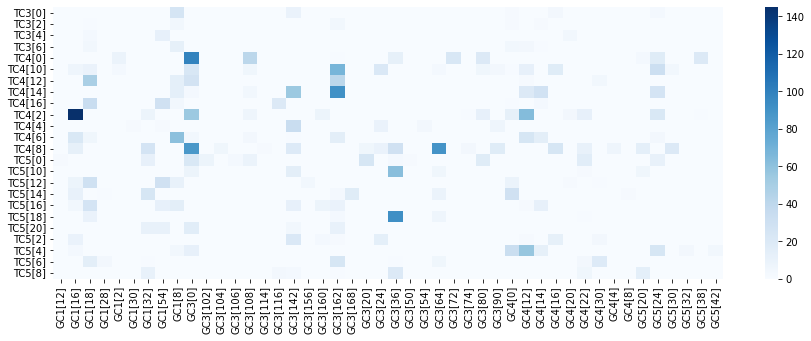

In [120]:
plot_synapse_heatmap(tc_syn_df)

In [121]:
tc_syn_df_ = get_syn_maxmin_df(tc_syn_df)
tc_syn_df_

,GC1[12],GC1[16],GC1[18],GC1[28],GC1[2],GC1[30],GC1[32],GC1[54],GC1[8],GC3[0],...,GC4[8],GC5[20],GC5[24],GC5[30],GC5[32],GC5[38],GC5[42],Row_Max,Max_idx,Row_Min
TC3[0],0,0,0,0,0,0,0,0,25,0,...,0,0,3,0,0,0,0,25,GC1[8],0
TC3[2],0,0,1,0,0,0,0,0,5,0,...,0,0,0,0,0,0,0,5,GC1[8],0
TC3[4],0,0,3,0,0,0,0,12,0,0,...,0,0,0,0,0,0,0,12,GC1[54],0
TC3[6],0,0,5,0,0,0,0,0,13,0,...,0,0,0,0,0,0,0,13,GC1[8],0
TC4[0],0,0,0,0,9,0,0,0,0,99,...,0,3,17,0,0,20,0,99,GC3[0],0
TC4[10],0,7,10,0,3,0,0,0,0,23,...,0,0,32,5,0,0,0,68,GC3[162],0
TC4[12],0,0,49,0,0,0,0,0,14,27,...,0,0,0,0,0,0,0,49,GC1[18],0
TC4[14],0,0,0,0,0,0,0,0,14,3,...,0,0,26,0,0,0,0,91,GC3[162],0
TC4[16],0,0,34,0,0,0,0,29,5,0,...,0,0,0,0,0,0,0,34,GC1[18],0
TC4[2],0,145,0,0,0,0,8,0,0,55,...,0,0,22,0,0,1,0,145,GC1[16],0


In [102]:
gcs_to_mcs = set(gcs_conn_to_mcs)
gcs_to_tcs = set(gcs_conn_to_tcs)
gcs_total = gcs_to_mcs.union(gcs_to_tcs)
len(gcs_total)


95

In [92]:
cell_types = ['MCs', 'TCs', 'GCs']

mc_radii, mc_children, mc_names = get_cell_info('MCs', slices_dir, slice_name)
tc_radii, tc_children, tc_names = get_cell_info('TCs', slices_dir, slice_name)
gc_radii, gc_children, gc_names = get_cell_info('GCs', slices_dir, slice_name)

# initialize cell info DataFrame
cols = 'num_cells', 'cells_syn_w_MCs', 'cells_syn_w_TCs', 'cells_syn_w_GCs', 'total_syn_w_MCs', 'total_syn_w_TCs', 'total_syn_w_GCs'
cell_df = pd.DataFrame(0, columns = cols, index = cell_types)

In [93]:
mc_radii

[[5.6364946365356445, 5.6364946365356445, 5.6364946365356445],
 [3.3566582202911377, 3.3566582202911377, 3.3566582202911377],
 [5.6364946365356445, 5.6364946365356445, 5.6364946365356445],
 [5.6364946365356445, 5.6364946365356445, 5.6364946365356445],
 [5.6364946365356445, 5.6364946365356445, 5.6364946365356445],
 [5.6364946365356445, 5.6364946365356445, 5.6364946365356445],
 [5.6364946365356445, 5.6364946365356445, 5.6364946365356445],
 [5.6364946365356445, 5.6364946365356445, 5.6364946365356445],
 [5.6364946365356445, 5.6364946365356445, 5.6364946365356445],
 [3.3566582202911377, 3.3566582202911377, 3.3566582202911377]]

In [94]:
cell_df.loc['MCs']['num_cells'] = len(mc_radii)
cell_df.loc['TCs']['num_cells'] = len(tc_radii)
cell_df.loc['GCs']['num_cells'] = len(gc_radii)
#assert(len(gc_radii)==len(gcs_total))  # check that the gcs that form synapses are the same gcs from GCs.json

cell_df.loc['MCs']['cells_syn_w_GCs'] = len(mcs_conn_to_gcs)
cell_df.loc['GCs']['cells_syn_w_MCs'] = len(gcs_conn_to_mcs)
cell_df.loc['TCs']['cells_syn_w_GCs'] = len(tcs_conn_to_gcs)
cell_df.loc['GCs']['cells_syn_w_TCs'] = len(gcs_conn_to_tcs)

cell_df.loc['MCs']['total_syn_w_GCs'] = len(mc_sect_to_gc)
cell_df.loc['GCs']['total_syn_w_MCs'] = len(gc_sect_to_mc)
cell_df.loc['TCs']['total_syn_w_GCs'] = len(tc_sect_to_gc)
cell_df.loc['GCs']['total_syn_w_TCs'] = len(gc_sect_to_tc)

cell_df

,num_cells,cells_syn_w_MCs,cells_syn_w_TCs,cells_syn_w_GCs,total_syn_w_MCs,total_syn_w_TCs,total_syn_w_GCs
MCs,10,0,0,10,0,0,3619
TCs,24,0,0,24,0,0,3042
GCs,115,115,46,0,3619,3042,0
